In [4]:
import pandas as pd

conv = pd.read_excel(
r"C:\Users\16094\OneDrive\chirsyu personal\OneDrive\BND_Bndinfo2.xlsx",
skiprows=2
)

print(conv.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\16094\\OneDrive\\chirsyu personal\\OneDrive\\BND_Bndinfo2.xlsx'

In [5]:
import pandas as pd

conv = pd.read_excel(
r"C:\Users\16094\OneDrive\chirsyu personal\OneDrive\BND_Bndinfo2.xlsx",
header=0,
skiprows=[1,2]
)

print(conv.columns)

Index(['Liscd', 'Abbrnme', 'Sctcd', 'Listdt', 'SecurityID', 'Bndnme', 'Curstu',
       'Bndyer', 'Bndtype', 'Bndexhp', 'Varsortcd', 'Varsort', 'Orgid',
       'Conme', 'IssSymbol', 'IssShortName', 'IssListedDate',
       'IssDelistedDate', 'IssExchangeCode', 'Currency', 'Acisuquty', 'Pooprc',
       'Ipotype', 'Term', 'Ipodt', 'Matdt', 'Intrdt', 'Stopdt', 'DelistedDate',
       'Ipaytypcd', 'Ipaytyp', 'Intrtypcd', 'Intrtyp', 'Pintrt', 'Intrrate',
       'Bemkrate', 'Basrted', 'Parval', 'Crdrate', 'InvestProject', 'Crdeem',
       'Rpchcls', 'Rdmdt', 'Rdemprc', 'Crtsell', 'Rtsellcls', 'Rtselldt',
       'Rtsellprc', 'Creplm', 'EarlyRepayClause', 'Whcrsmak', 'Crsmakpl',
       'Whseprat', 'IntBss', 'FrstPyIntDt', 'OptType', 'CallOrPut',
       'RtOptStCycle', 'RtOptFltClng', 'RtOptFltFlr', 'UnderwritedMethods',
       'IssueObject', 'OnlineIssueShares', 'OnlineIssueLimit',
       'OnlineIssueStartDate', 'OnlineIssueEndDate', 'IssueEndDate'],
      dtype='str')


In [6]:
conv = conv[
[
"SecurityID",
"Conme",
"Crdrate",
"Intrtyp",
"Currency",
"Term",
"Ipodt",
"Intrrate"
]
]

In [7]:
print(len(conv))

102397


In [8]:
import pandas as pd

# =========================
# 1 读取绿色债券
# =========================

green = pd.read_excel(
r"C:\Users\16094\OneDrive\chirsyu personal\OneDrive\GF_1848_MonthlyMatched_Spread_clean.xlsx"
)

green["IssueDate"] = pd.to_datetime(green["IssueDate"])


# =========================
# 2 读取普通债券
# =========================

conv = pd.read_excel(
r"C:\Users\16094\OneDrive\chirsyu personal\OneDrive\BND_Bndinfo2.xlsx",
header=0,
skiprows=[1,2]
)

# 只保留需要的列
conv = conv[
[
"SecurityID",
"Conme",
"Crdrate",
"Intrtyp",
"Currency",
"Term",
"Ipodt",
"Intrrate"
]
]

# 数据清洗
conv = conv.dropna()

conv["Term"] = pd.to_numeric(conv["Term"], errors="coerce")
conv["Intrrate"] = pd.to_numeric(conv["Intrrate"], errors="coerce")
conv["Ipodt"] = pd.to_datetime(conv["Ipodt"], errors="coerce")

conv = conv.dropna()


# =========================
# 3 匹配算法
# =========================

matches = []

for i, g in green.iterrows():

    # Step1：评级、利率类型、货币
    cand = conv[
        (conv["Crdrate"] == g["BondCreditLevel"]) &
        (conv["Intrtyp"] == g["RateType"]) &
        (conv["Currency"] == g["Currency"])
    ]

    if len(cand) == 0:
        continue

    # Step2：发行时间限制
    cand = cand[
        abs((cand["Ipodt"] - g["IssueDate"]).dt.days) <= 365*6
    ]

    if len(cand) == 0:
        continue

    # Step3：期限差
    cand["TermDiff"] = abs(cand["Term"] - g["BondTermYears"])

    cand = cand[cand["TermDiff"] <= 1]

    if len(cand) == 0:
        continue

    # Step4：选期限最接近
    best = cand.loc[cand["TermDiff"].idxmin()]

    matches.append({
        "GreenBondID": g["BondID"],
        "ConvBondID": best["SecurityID"],
        "GreenIssuer": g["Issuer"],
        "ConvIssuer": best["Conme"],
        "GreenYield": g["ParValueRate"],
        "ConvYield": best["Intrrate"],
        "TermDiff": best["TermDiff"],
        "DateDiff_days": abs((best["Ipodt"] - g["IssueDate"]).days)
    })


# =========================
# 4 输出结果
# =========================

match_df = pd.DataFrame(matches)

match_df.to_excel(
r"C:\Users\16094\OneDrive\chirsyu personal\OneDrive\Green_Conv_MatchedPairs.xlsx",
index=False
)

print("绿色债券数量:", len(green))
print("成功匹配数量:", len(match_df))

KeyError: 'RateType'

In [9]:
print(green.columns)

Index(['BondID', 'Symbol', 'ShortName', 'IssueDate', 'FullName',
       'ExchangeCode', 'Issuer', 'PeriodTime', 'BondNature', 'BondTerm',
       'Ipaytyp', 'IssueMode', 'IssueScale', 'ParValueRate',
       'SubscriptionRatio', 'InterestStartDate', 'ListedDate', 'DelistedDate',
       'MaturityDate', 'BondCreditLevel', 'IssuerCreditLevel',
       'BondRatingInstitution', 'IssuerRatingInstitution',
       'TrusteeInstitution', 'Udwnm', 'InvestProject', 'Comments',
       'IsGuarantee', 'IsCrossMarket', 'Explanation', 'IsSeparation',
       'IsRedeem', 'RedeemClause', 'RedeemDate', 'RedeemPrice', 'IsSaleBack',
       'SaleBackClause', 'SaleBackDate', 'SaleBackPrice', 'BondCreditScore',
       'IssuerCreditScore', 'BondNatureCode', 'BondNatureGroup',
       'BondNatureGroupCode', 'YearMonth', 'BondTermYears',
       'Matched_TreasuryYield', 'Green_Treasury_Spread'],
      dtype='str')


In [11]:
import pandas as pd

# =====================
# 1 读取绿色债券
# =====================

green = pd.read_excel(
r"C:\Users\16094\OneDrive\chirsyu personal\OneDrive\GF_1848_MonthlyMatched_Spread_clean.xlsx"
)

green["IssueDate"] = pd.to_datetime(green["IssueDate"])


# =====================
# 2 读取普通债券
# =====================

conv = pd.read_excel(
r"C:\Users\16094\OneDrive\chirsyu personal\OneDrive\BND_Bndinfo2.xlsx",
header=0,
skiprows=[1,2]
)

conv = conv[
[
"SecurityID",
"Conme",
"Crdrate",
"Currency",
"Term",
"Ipodt",
"Intrrate"
]
]

conv = conv.dropna()

conv["Term"] = pd.to_numeric(conv["Term"], errors="coerce")
conv["Intrrate"] = pd.to_numeric(conv["Intrrate"], errors="coerce")
conv["Ipodt"] = pd.to_datetime(conv["Ipodt"], errors="coerce")

conv = conv.dropna()


# =====================
# 3 匹配算法
# =====================

matches = []

for i, g in green.iterrows():

    cand = conv[
        (conv["Crdrate"] == g["BondCreditLevel"])
    ]

    if len(cand) == 0:
        continue

    # 时间限制
    cand = cand[
        abs((cand["Ipodt"] - g["IssueDate"]).dt.days) <= 365*6
    ]

    if len(cand) == 0:
        continue

    # 期限差
    cand["TermDiff"] = abs(cand["Term"] - g["BondTermYears"])

    cand = cand[cand["TermDiff"] <= 1]

    if len(cand) == 0:
        continue

    best = cand.loc[cand["TermDiff"].idxmin()]

    matches.append({
        "GreenBondID": g["BondID"],
        "ConvBondID": best["SecurityID"],
        "GreenIssuer": g["Issuer"],
        "ConvIssuer": best["Conme"],
        "GreenYield": g["ParValueRate"],
        "ConvYield": best["Intrrate"],
        "TermDiff": best["TermDiff"],
        "DateDiff_days": abs((best["Ipodt"] - g["IssueDate"]).days)
    })


# =====================
# 4 输出结果
# =====================

match_df = pd.DataFrame(matches)

match_df.to_excel(
r"C:\Users\16094\OneDrive\chirsyu personal\OneDrive\Green_Conv_MatchedPairs.xlsx",
index=False
)

print("绿色债券数量:", len(green))
print("成功匹配数量:", len(match_df))

绿色债券数量: 1673
成功匹配数量: 1665


In [12]:
match_df["ConvSpread"] = match_df["ConvYield"] - match_df["Matched_TreasuryYield"]

KeyError: 'Matched_TreasuryYield'

In [13]:
print(match_df.columns)

Index(['GreenBondID', 'ConvBondID', 'GreenIssuer', 'ConvIssuer', 'GreenYield',
       'ConvYield', 'TermDiff', 'DateDiff_days'],
      dtype='str')


In [14]:
match_df = match_df.merge(
    green[["BondID","Matched_TreasuryYield","Green_Treasury_Spread"]],
    left_on="GreenBondID",
    right_on="BondID",
    how="left"
)

In [15]:
print(match_df.columns)

Index(['GreenBondID', 'ConvBondID', 'GreenIssuer', 'ConvIssuer', 'GreenYield',
       'ConvYield', 'TermDiff', 'DateDiff_days', 'BondID',
       'Matched_TreasuryYield', 'Green_Treasury_Spread'],
      dtype='str')


In [16]:
match_df["ConvSpread"] = (
    match_df["ConvYield"] - match_df["Matched_TreasuryYield"]
)

In [17]:
match_df["Greenium"] = (
    match_df["Green_Treasury_Spread"] - match_df["ConvSpread"]
)

In [18]:
print(match_df["Greenium"].describe())

count    2030.000000
mean       -0.484576
std         1.705333
min        -5.450000
25%        -1.710000
50%        -0.210000
75%         0.650000
max         4.050000
Name: Greenium, dtype: float64


In [20]:
from scipy import stats
stats.ttest_1samp(match_df["Greenium"],0)


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [21]:
match_df["Greenium"].isna().sum()

np.int64(3)

In [22]:
from scipy import stats

stats.ttest_1samp(match_df["Greenium"].dropna(), 0)

TtestResult(statistic=np.float64(-12.802681791728594), pvalue=np.float64(3.811912963519784e-36), df=np.int64(2029))

In [24]:
print(match_df.columns)


Index(['GreenBondID', 'ConvBondID', 'GreenIssuer', 'ConvIssuer', 'GreenYield',
       'ConvYield', 'TermDiff', 'DateDiff_days', 'BondID',
       'Matched_TreasuryYield', 'Green_Treasury_Spread', 'ConvSpread',
       'Greenium'],
      dtype='str')


In [25]:
match_df = match_df.merge(
    green[[
        "BondID",
        "BondTermYears",
        "IssueScale",
        "BondCreditLevel",
        "BondNature",
        "YearMonth",
        "Issuer"
    ]],
    left_on="GreenBondID",
    right_on="BondID",
    how="left"
)

In [26]:
print(match_df.columns)

Index(['GreenBondID', 'ConvBondID', 'GreenIssuer', 'ConvIssuer', 'GreenYield',
       'ConvYield', 'TermDiff', 'DateDiff_days', 'BondID_x',
       'Matched_TreasuryYield', 'Green_Treasury_Spread', 'ConvSpread',
       'Greenium', 'BondID_y', 'BondTermYears', 'IssueScale',
       'BondCreditLevel', 'BondNature', 'YearMonth', 'Issuer'],
      dtype='str')


In [27]:
match_df = match_df.drop(columns=["BondID_y"])
match_df = match_df.rename(columns={"BondID_x": "BondID"})

In [28]:
print(match_df.columns)

Index(['GreenBondID', 'ConvBondID', 'GreenIssuer', 'ConvIssuer', 'GreenYield',
       'ConvYield', 'TermDiff', 'DateDiff_days', 'BondID',
       'Matched_TreasuryYield', 'Green_Treasury_Spread', 'ConvSpread',
       'Greenium', 'BondTermYears', 'IssueScale', 'BondCreditLevel',
       'BondNature', 'YearMonth', 'Issuer'],
      dtype='str')


In [29]:
green_unique = green.drop_duplicates(subset=["BondID"])

In [30]:
match_df = match_df.merge(
    green_unique[[
        "BondID",
        "BondTermYears",
        "IssueScale",
        "BondCreditLevel",
        "BondNature",
        "YearMonth",
        "Issuer"
    ]],
    left_on="GreenBondID",
    right_on="BondID",
    how="left"
)

In [31]:
len(match_df)

2769

In [32]:
green["BondID"].value_counts().head()

BondID
54265    2
68211    2
68212    2
69136    2
69278    2
Name: count, dtype: int64

In [33]:
green_unique = green.drop_duplicates(subset=["BondID"])

In [34]:
green_unique["BondID"].duplicated().sum()

np.int64(0)

In [35]:
match_df = match_df.merge(
    green_unique[
        [
            "BondID",
            "BondTermYears",
            "IssueScale",
            "BondCreditLevel",
            "BondNature",
            "YearMonth",
            "Issuer"
        ]
    ],
    left_on="GreenBondID",
    right_on="BondID",
    how="left"
)

In [36]:
len(match_df)

2769

In [37]:
match_df["GreenBondID"].value_counts().head()

GreenBondID
54265    8
68211    8
68212    8
69136    8
69278    8
Name: count, dtype: int64

In [38]:
match_df = match_df.drop_duplicates(subset="GreenBondID")

In [39]:
len(match_df)

1481

In [40]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Greenium ~ BondTermYears + IssueScale + C(BondCreditLevel) + C(YearMonth)",
    data=match_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Greenium   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     17.32
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          6.93e-202
Time:                        15:46:52   Log-Likelihood:                -2176.5
No. Observations:                1477   AIC:                             4601.
Df Residuals:                    1353   BIC:                             5258.
Df Model:                         123                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [41]:
model = smf.ols(
    "Greenium ~ BondTermYears \
               + IssueScale \
               + C(BondCreditLevel) \
               + C(BondNature) \
               + C(YearMonth)",
    data=match_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Greenium   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     18.67
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          1.03e-227
Time:                        15:50:40   Log-Likelihood:                -2082.2
No. Observations:                1477   AIC:                             4442.
Df Residuals:                    1338   BIC:                             5179.
Df Model:                         138                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [42]:
model = smf.ols(
    "Greenium ~ BondTermYears + IssueScale + C(BondCreditLevel) + C(BondNature) + C(YearMonth)",
    data=match_df
).fit(cov_type="HC3")

In [44]:
match_df["Year"] = match_df["YearMonth"].str[:4]

model = smf.ols(
    "Greenium ~ BondTermYears + IssueScale + C(BondCreditLevel) + C(BondNature) + C(Year)",
    data=match_df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Greenium   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     234.5
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:53:39   Log-Likelihood:                -2189.0
No. Observations:                1477   AIC:                             4442.
Df Residuals:                    1445   BIC:                             4611.
Df Model:                          31                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [46]:
match_df["Year"] = match_df["YearMonth"].str[:4]

model = smf.ols(
    "Greenium ~ BondTermYears + IssueScale + C(BondCreditLevel) + C(BondNature) + C(Year)",
    data=match_df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Greenium   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     234.5
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:54:59   Log-Likelihood:                -2189.0
No. Observations:                1477   AIC:                             4442.
Df Residuals:                    1445   BIC:                             4611.
Df Model:                          31                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [50]:
match_df["Issuer"].dtype

<StringDtype(storage='python', na_value=nan)>

In [51]:
match_df["IssuerID"] = match_df["Issuer"].astype("category").cat.codes

In [52]:
match_df["IssuerID"].dtype

dtype('int16')

In [56]:
import statsmodels.formula.api as smf

df = match_df.dropna(subset=[
    "Greenium",
    "BondTermYears",
    "IssueScale",
    "BondCreditLevel",
    "Year",
    "IssuerID"
])

model = smf.ols(
    "Greenium ~ BondTermYears + IssueScale + C(BondCreditLevel) + C(Year)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["IssuerID"]}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Greenium   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     105.3
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          6.69e-163
Time:                        16:01:37   Log-Likelihood:                -2277.8
No. Observations:                1477   AIC:                             4590.
Df Residuals:                    1460   BIC:                             4680.
Df Model:                          16                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [57]:
match_df["GreenBondID"].value_counts().head()

GreenBondID
54265    1
55284    1
58919    1
59826    1
59827    1
Name: count, dtype: int64

In [58]:
match_df["Greenium"].mean()

np.float64(-0.7932679296346414)

In [59]:
GreenYield = 3.5

In [60]:
match_df["GreenYield"].describe()

count    1478.000000
mean        3.600636
std         1.307073
min         0.100000
25%         2.700000
50%         3.360000
75%         4.300000
max         7.800000
Name: GreenYield, dtype: float64

In [61]:
import numpy as np

match_df["Greenium_w"] = match_df["Greenium"].clip(
    lower=match_df["Greenium"].quantile(0.01),
    upper=match_df["Greenium"].quantile(0.99)
)

match_df["Greenium_w"].mean()

np.float64(-0.7963389715832206)

In [62]:
match_df.to_excel("green_bond_matched_sample.xlsx", index=False)

In [66]:
match_df.to_excel(r"C:\Users\16094\Desktop\green_bond_matched_sample.xlsx", index=False)

In [67]:
match_df.to_excel(
    r"C:\Users\16094\Desktop\green_bond_matched_sample.xlsx",
    index=False
)

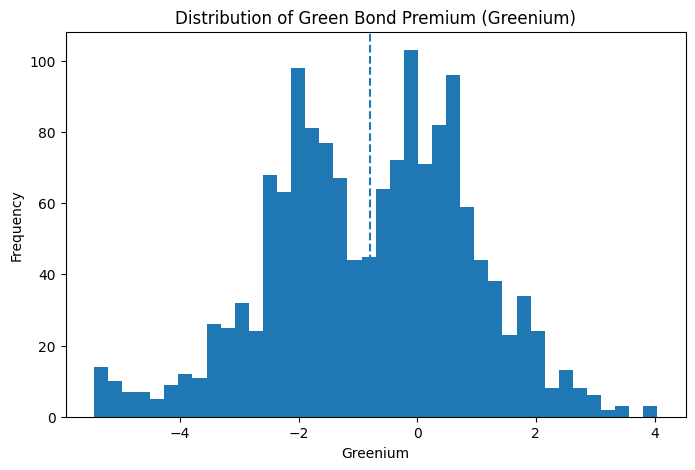

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(match_df["Greenium"], bins=40)

plt.axvline(match_df["Greenium"].mean(), linestyle="--")

plt.title("Distribution of Green Bond Premium (Greenium)")
plt.xlabel("Greenium")
plt.ylabel("Frequency")

plt.show()

In [70]:
year_greenium = match_df.groupby("Year")["Greenium"].mean()

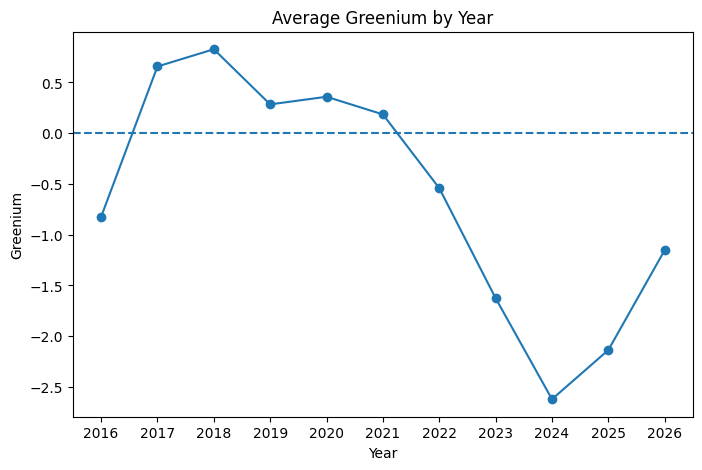

In [71]:
plt.figure(figsize=(8,5))

plt.plot(year_greenium.index, year_greenium.values, marker="o")

plt.axhline(0, linestyle="--")

plt.title("Average Greenium by Year")
plt.xlabel("Year")
plt.ylabel("Greenium")

plt.show()

In [ ]:
git --version

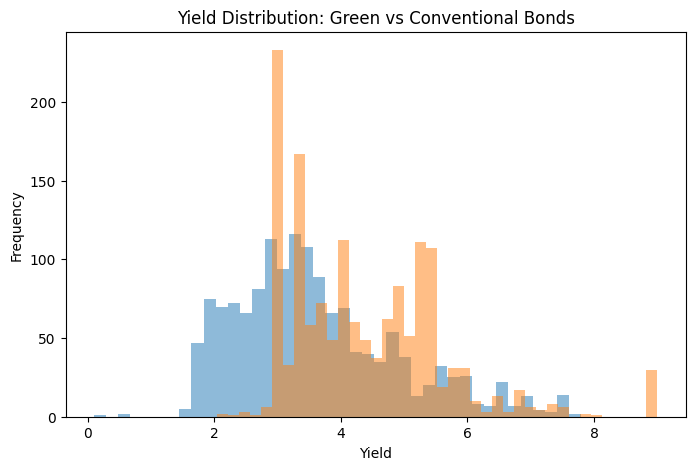

In [72]:
plt.figure(figsize=(8,5))

plt.hist(match_df["GreenYield"], bins=40, alpha=0.5)
plt.hist(match_df["ConvYield"], bins=40, alpha=0.5)

plt.title("Yield Distribution: Green vs Conventional Bonds")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.show()

In [73]:
plt.savefig("figure1_greenium_distribution.png", dpi=300)

<Figure size 640x480 with 0 Axes>

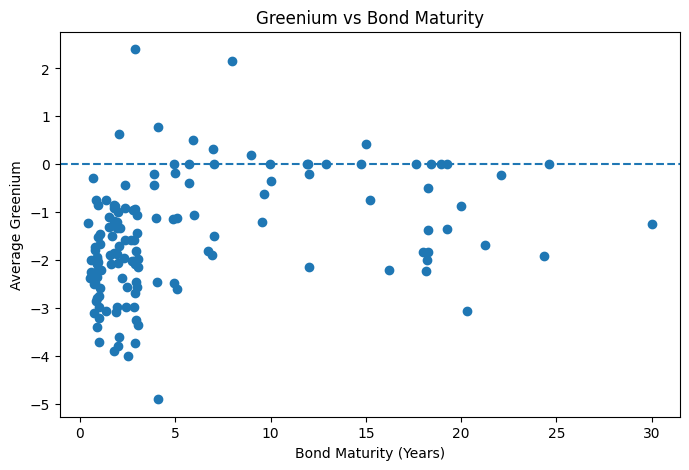

In [74]:
import matplotlib.pyplot as plt

# 按期限分组
maturity_greenium = match_df.groupby("BondTermYears")["Greenium"].mean()

plt.figure(figsize=(8,5))

plt.scatter(maturity_greenium.index, maturity_greenium.values)

plt.axhline(0, linestyle="--")

plt.title("Greenium vs Bond Maturity")
plt.xlabel("Bond Maturity (Years)")
plt.ylabel("Average Greenium")

plt.show()

In [75]:
match_df.head()

,GreenBondID,ConvBondID,GreenIssuer,ConvIssuer,GreenYield,ConvYield,TermDiff,DateDiff_days,BondID_x,Matched_TreasuryYield,...,BondID,BondTermYears,IssueScale,BondCreditLevel,BondNature,YearMonth,Issuer,Year,IssuerID,Greenium_w
0,54265,203000044020,北京汽车股份有限公司,徐州市贾汪城市建设投资有限公司,3.45,4.00,0.0,30,54265,2.7777,...,54265,7.0,25.0,AAA,企业债,2016-04,北京汽车股份有限公司,2016,123,-0.55
8,55284,203000044692,浙江嘉化能源化工股份有限公司,柳州市龙建投资发展有限责任公司,4.78,4.45,0.0,54,55284,2.7092,...,55284,5.0,3.0,AA,公司普通债,2016-05,浙江嘉化能源化工股份有限公司,2016,441,0.33
9,58919,203000041711,华能新能源股份有限公司,上海复星医药(集团)股份有限公司,2.95,3.35,0.0,130,58919,2.6556,...,58919,5.0,11.4,AAA,公司普通债,2016-07,华能新能源股份有限公司,2016,144,-0.40
10,59826,203000042307,江西银行股份有限公司,海亮集团有限公司,3.41,5.30,0.0,124,59826,2.5293,...,59826,3.0,35.0,AA+,商业银行普通金融债,2016-07,江西银行股份有限公司,2016,418,-1.89
11,59827,203000042190,江西银行股份有限公司,融创房地产集团有限公司,3.70,5.40,0.0,128,59827,2.6556,...,59827,5.0,15.0,AA+,商业银行普通金融债,2016-07,江西银行股份有限公司,2016,418,-1.70


In [76]:
match_df.to_excel(
    r"C:\Users\16094\Desktop\green_bond_matched.xlsx",
    index=False
)

In [77]:
match_df.to_excel(
    r"C:\Users\16094\Desktop\green_bond_matched.xlsx",
    index=False
)

In [78]:
match_df.to_excel("green_bond_matched.xlsx", index=False)

In [79]:
match_df.to_excel("green_bond_matched.xlsx", index=False)

In [80]:
plt.savefig("yield_comparison.png", dpi=300)

<Figure size 640x480 with 0 Axes>

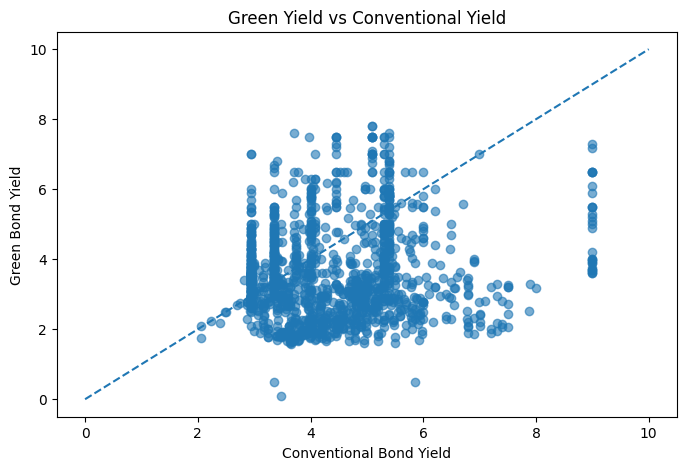

In [81]:
plt.figure(figsize=(8,5))

plt.scatter(match_df["ConvYield"], match_df["GreenYield"], alpha=0.6)

plt.plot([0,10], [0,10], linestyle="--")

plt.title("Green Yield vs Conventional Yield")
plt.xlabel("Conventional Bond Yield")
plt.ylabel("Green Bond Yield")

plt.savefig("yield_comparison.png", dpi=300)

plt.show()

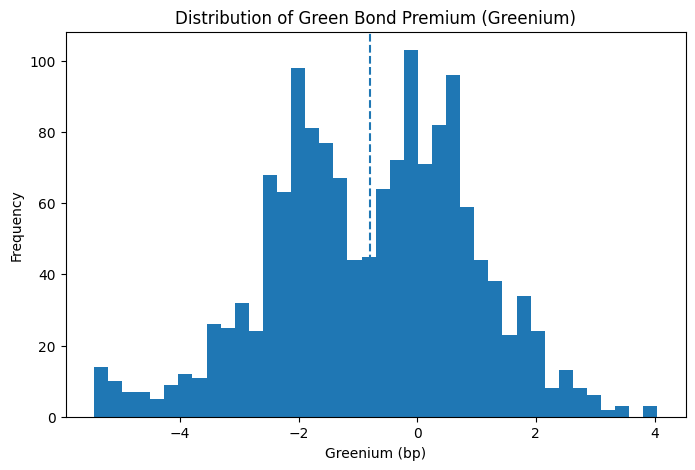

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(match_df["Greenium"], bins=40)

plt.axvline(match_df["Greenium"].mean(), linestyle="--")

plt.title("Distribution of Green Bond Premium (Greenium)")
plt.xlabel("Greenium (bp)")
plt.ylabel("Frequency")

plt.savefig("greenium_distribution.png", dpi=300)

plt.show()

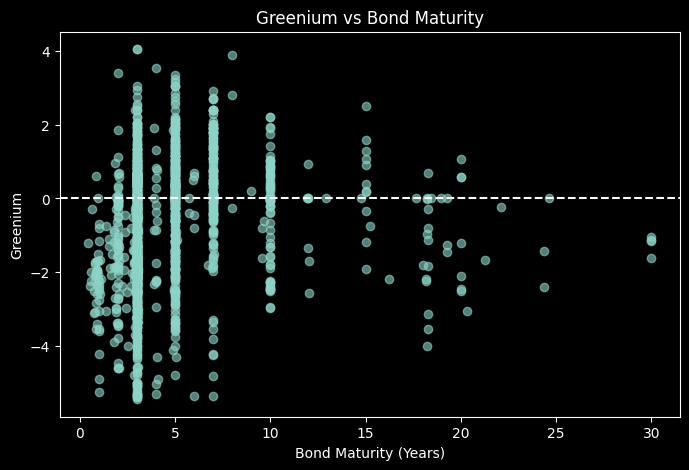

In [84]:
plt.figure(figsize=(8,5))

plt.scatter(match_df["BondTermYears"], match_df["Greenium"], alpha=0.6)

plt.axhline(0, linestyle="--")

plt.title("Greenium vs Bond Maturity")
plt.xlabel("Bond Maturity (Years)")
plt.ylabel("Greenium")

plt.savefig("greenium_vs_maturity.png", dpi=300)

plt.show()

In [3]:
plt.figure(figsize=(8,5))

plt.scatter(match_df["ConvYield"], match_df["GreenYield"], alpha=0.6)

plt.plot([0,10], [0,10], linestyle="--")

plt.title("Green Yield vs Conventional Yield")
plt.xlabel("Conventional Bond Yield")
plt.ylabel("Green Bond Yield")

plt.savefig("yield_comparison.png", dpi=300)

plt.show()

NameError: name 'plt' is not defined

In [87]:
match_df.to_excel(
    r"C:\Users\16094\Desktop\green_vs_conventional_bonds.xlsx",
    index=False
)

In [88]:
match_df["Greenium_spread"] = match_df["Green_Treasury_Spread"] - match_df["ConvSpread"]
match_df["Greenium_spread"].describe()

count    1478.000000
mean       -0.793268
std         1.694697
min        -5.450000
25%        -1.990000
50%        -0.610000
75%         0.450000
max         4.050000
Name: Greenium_spread, dtype: float64

In [89]:
vars = [
    "GreenYield",
    "ConvYield",
    "Greenium",
    "BondTermYears",
    "IssueScale"
]

desc_table = match_df[vars].describe()

print(desc_table)

        GreenYield    ConvYield     Greenium  BondTermYears   IssueScale
count  1478.000000  1481.000000  1478.000000    1481.000000  1480.000000
mean      3.600636     4.394943    -0.793268       4.624099    18.887054
std       1.307073     1.266348     1.694697       3.509952    38.983343
min       0.100000     2.050000    -5.450000       0.420000     0.280000
25%       2.700000     3.350000    -1.990000       3.000000     5.000000
50%       3.360000     4.150000    -0.610000       3.000000    10.000000
75%       4.300000     5.300000     0.450000       5.000000    15.000000
max       7.800000     9.000000     4.050000      30.000000   500.000000


In [90]:
corr_vars = [
    "GreenYield",
    "ConvYield",
    "Greenium",
    "BondTermYears",
    "IssueScale"
]

corr_table = match_df[corr_vars].corr()

print(corr_table)

               GreenYield  ConvYield  Greenium  BondTermYears  IssueScale
GreenYield       1.000000   0.132084  0.672674       0.158178   -0.203759
ConvYield        0.132084   1.000000 -0.644606      -0.033258   -0.109417
Greenium         0.672674  -0.644606  1.000000       0.146358   -0.075613
BondTermYears    0.158178  -0.033258  0.146358       1.000000   -0.038718
IssueScale      -0.203759  -0.109417 -0.075613      -0.038718    1.000000


In [94]:
reg_df = match_df.dropna(subset=[
    "Greenium",
    "BondTermYears",
    "IssueScale",
    "BondCreditLevel",
    "Year",
    "IssuerID"
])

In [95]:
reg_df = match_df.dropna(subset=[
    "Greenium",
    "BondTermYears",
    "IssueScale",
    "BondCreditLevel",
    "Year",
    "IssuerID"
])

In [96]:
print(len(reg_df))

1477


In [97]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Greenium ~ BondTermYears + IssueScale + C(BondCreditLevel) + C(Year)",
    data=reg_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["IssuerID"]}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Greenium   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     105.3
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          6.69e-163
Time:                        16:39:15   Log-Likelihood:                -2277.8
No. Observations:                1477   AIC:                             4590.
Df Residuals:                    1460   BIC:                             4680.
Df Model:                          16                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [98]:
match_df.to_excel(
    r"C:\Users\16094\Desktop\green_conventional_matched_pairs.xlsx",
    index=False
)

print("Excel 已导出到桌面")

Excel 已导出到桌面


In [99]:
import os

desktop = os.path.join(os.path.expanduser("~"), "Desktop")

match_df.to_excel(
    os.path.join(desktop, "green_bond_matched_pairs.xlsx"),
    index=False
)

In [100]:
import os
print(os.getcwd())

C:\Users\16094\PycharmProjects\JupyterProject


In [101]:
import os

desktop = os.path.join(os.path.expanduser("~"), "Desktop")

match_df.to_excel(
    os.path.join(desktop, "green_bond_matched_pairs.xlsx"),
    index=False
)

In [102]:
import os

desktop = os.path.join(os.path.expanduser("~"), "Desktop")

match_df.to_excel(
    os.path.join(desktop, "green_bond_matched_pairs.xlsx"),
    index=False
)

In [103]:
match_df.to_excel("green_bond_matched_pairs.xlsx", index=False)

print("Excel 已保存到当前 Python 文件夹")

Excel 已保存到当前 Python 文件夹


In [104]:
import os
print(os.listdir())

['.idea', '.venv', 'data', 'dickhead.ipynb', 'greenium_distribution.png', 'greenium_vs_maturity.png', 'green_bond_matched_pairs.xlsx', 'models', 'README.md', 'requirements.txt', 'sample.ipynb', 'yield_comparison.png']
